In [12]:
# Load CSV
import pandas as pd

df = pd.read_csv('avocado.csv')

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  str    
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  str    
 12  year          18249 non-null  int64  
 13  region        18249 non-null  str    
dtypes: float64(9), int64(2), str(3)
memory usage: 1.9 MB


In [3]:
# Check for Missing Values
df.isnull().sum()

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [4]:
# Display unique values in 'type' and 'region' columns
print("Unique values in 'type' column:")
print(df['type'].unique())
print(f"\nTotal unique types: {df['type'].nunique()}\n")

print("Unique values in 'region' column:")
print(df['region'].unique())
print(f"\nTotal unique regions: {df['region'].nunique()}")

Unique values in 'type' column:
<StringArray>
['conventional', 'organic']
Length: 2, dtype: str

Total unique types: 2

Unique values in 'region' column:
<StringArray>
[             'Albany',             'Atlanta', 'BaltimoreWashington',
               'Boise',              'Boston',    'BuffaloRochester',
          'California',           'Charlotte',             'Chicago',
    'CincinnatiDayton',            'Columbus',       'DallasFtWorth',
              'Denver',             'Detroit',         'GrandRapids',
          'GreatLakes',  'HarrisburgScranton', 'HartfordSpringfield',
             'Houston',        'Indianapolis',        'Jacksonville',
            'LasVegas',          'LosAngeles',          'Louisville',
   'MiamiFtLauderdale',            'Midsouth',           'Nashville',
    'NewOrleansMobile',             'NewYork',           'Northeast',
  'NorthernNewEngland',             'Orlando',        'Philadelphia',
       'PhoenixTucson',          'Pittsburgh',              'P

In [13]:
# Encode (Label Encoding)
'''
ML Models only understand numbers, not text.
"California" and "Hass" are text values so they need to be converted to numbers before training a model.
'''

from category_encoders import TargetEncoder
from sklearn.preprocessing import OneHotEncoder

te = TargetEncoder()
ohe = OneHotEncoder()

# type (one-hot encoding - creates multiple columns)
type_encoded = ohe.fit_transform(df[['type']])
# Convert sparse matrix to DataFrame and add to df
type_encoded_df = pd.DataFrame(type_encoded.toarray(), columns=ohe.get_feature_names_out(['type']))
df = pd.concat([df, type_encoded_df], axis=1)

# region (target encoding - single column)
df['region_encoded'] = te.fit_transform(df[['region']], df['AveragePrice'])

In [15]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,type_conventional,type_organic,region_encoded
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,1.0,0.0,1.561036
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,1.0,0.0,1.561036
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,1.0,0.0,1.561036
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,1.0,0.0,1.561036
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,1.0,0.0,1.561036


In [18]:
# Drop unnecessary columns (index, date) and separate X, y
X = df.drop(['Unnamed: 0', 'Date', 'AveragePrice', 'type', 'region'], axis=1)
y = df['AveragePrice']

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Evaluate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

y_pred = lr.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)  # Average error in $
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Percentage error

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: ${mae:.2f}")  # More interpretable
print(f"MAPE: {mape:.2f}%")

R² Score: 0.5484
RMSE: 0.27
MAE: $0.20
MAPE: 15.31%


Random Forest R²: 0.8694


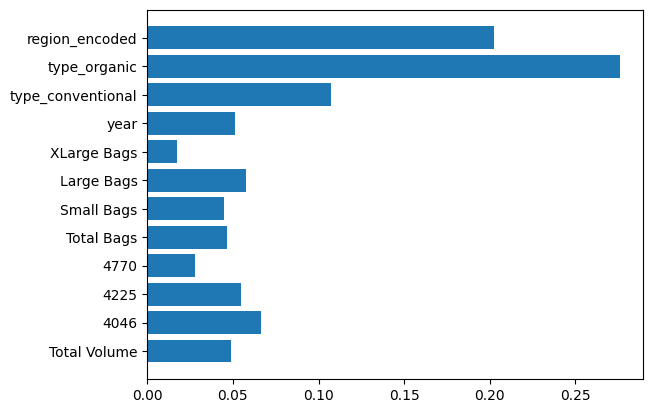

CV R² Mean: 0.5594 (+/- 0.0144)


In [20]:
# 1. Compare with other models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print(f"Random Forest R²: {r2_score(y_test, rf_pred):.4f}")

# 2. Feature importance
import matplotlib.pyplot as plt
plt.barh(X.columns, rf.feature_importances_)
plt.show()

# 3. Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')
print(f"CV R² Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

In [27]:
# Save model + scaler together
import pickle

data = {
    'model': rf,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}

with open('avocado_model_full.pkl', 'wb') as f:
    pickle.dump(data, f)

# Load
with open('avocado_model_full.pkl', 'rb') as f:
    data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']

In [28]:
with open('avocado_model_full.pkl', 'rb') as f:
    data = pickle.load(f)  # Load the dictionary
    model = data['model']  # Extract the actual model
    scaler_loaded = data['scaler']
    feature_names = data['feature_names']

test_predictions = model.predict(X_test_scaled)

# Compare
results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': test_predictions,
    'Difference': y_test.values - test_predictions,
    'Error %': (np.abs(y_test.values - test_predictions) / y_test.values * 100)
})

print("Sample Predictions (first 10):")
print(results.head(10))

print(f"\nAverage Error: ${results['Difference'].abs().mean():.4f}")
print(f"Max Error: ${results['Difference'].abs().max():.4f}")
print(f"Min Error: ${results['Difference'].abs().min():.4f}")

Sample Predictions (first 10):
   Actual Price  Predicted Price  Difference    Error %
0          0.82           1.0668     -0.2468  30.097561
1          0.97           1.0120     -0.0420   4.329897
2          1.44           1.4026      0.0374   2.597222
3          0.97           0.9199      0.0501   5.164948
4          1.45           1.4530     -0.0030   0.206897
5          1.29           1.4169     -0.1269   9.837209
6          2.03           1.7105      0.3195  15.738916
7          0.94           0.9676     -0.0276   2.936170
8          2.45           2.3103      0.1397   5.702041
9          1.83           1.6372      0.1928  10.535519

Average Error: $0.1027
Max Error: $0.8909
Min Error: $0.0000
